# It Takes Time: Intensity-Aware Sequential Recommendation Benchmark

Goal: rank a battery of sequential / temporal collaborative-filtering models on
**MovieLens-1M**, **MovieLens-100K**, and Amazon Reviews 5-core (**Digital Music**, **Office Products**) under a single, reproducible methodology, and
produce results tables that compare standard SOTA baselines against three new
**IA-SASRec** (Intensity-Aware SASRec) variants that inject per-interaction
intensity (ratings / hours-played) directly into the self-attention mechanism.

**Models compared**

| Family | Models |
|---|---|
| Non-sequential baselines | `Pop`, `BPR`, `ItemKNN` |
| Sequential SOTA | `FPMC`, `GRU4Rec`, `NARM`, `SASRec`, `BERT4Rec` |
| **IA-SASRec (new)** | `IA-SASRec-Add`, `IA-SASRec-Mul`, `IA-SASRec-Val` |

**Methodology**

- Datasets: ML-1M, ML-100K, Amazon Digital Music 5-core, Amazon Office Products 5-core.
  All four use rating as intensity and ship with native unix timestamps. Steam-200k is
  excluded from sequential experiments — its CSV has no timestamps. All datasets are
  filtered to users/items with >= 5 interactions.
- Split: leave-one-out per user, sorted chronologically (`LS=valid_and_test`, `order=TO`).
- HPO: Optuna TPE + MedianPruner, `N_TRIALS=10` by default.
- Eval: full-vocabulary scoring -> HitRate, NDCG, MRR, Recall, Precision @ {10, 20, 50, 100}.
- Resumability: results persisted to `results/eval/<dataset>__<model>.json`;
  Optuna studies persist to SQLite under `results/hpo/`.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import optuna

import config
from data import prepare_recbole_dataset, dataset_stats
from models import MODEL_REGISTRY, list_models
from hpo import run_optuna
from runner import train_and_eval, has_result, load_result
from evaluation import aggregate_results, top_k_recommend

print('device:', config.DEVICE)
print('models:', list_models())
print('N_TRIALS:', config.N_TRIALS, '| HPO_EPOCHS:', config.HPO_EPOCHS, '| FINAL_EPOCHS:', config.FINAL_EPOCHS)

2026-05-21 12:16:29.462176: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-21 12:16:29.532353: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-21 12:16:31.191688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


device: cuda
models: ['Pop', 'BPR', 'ItemKNN', 'FPMC', 'GRU4Rec', 'NARM', 'SASRec', 'BERT4Rec', 'IA-SASRec-Add', 'IA-SASRec-Mul', 'IA-SASRec-Val']
N_TRIALS: 25 | HPO_EPOCHS: 10 | FINAL_EPOCHS: 50


## 2. Dataset preparation

Downloads MovieLens-1M (~6 MB), MovieLens-100K (~5 MB), Amazon Digital Music
5-core (~5 MB), and Amazon Office Products 5-core (~5 MB) on first run,
converts each to RecBole atomic-file format, and caches under
`recbole_data/<dataset>/<dataset>.inter`. Subsequent runs are no-ops.

In [2]:
DATASETS = ['amazon-digital-music', 'amazon-office-products', 'ml-100k-iar', 'ml-1m']
# Note: 'ml-100k-iar' (Intensity-Aware) — NOT plain 'ml-100k'.
# RecBole 1.2.0 hard-codes a special case for dataset name == 'ml-100k' that
# overrides our data_path to its bundled 3-column example file, silently
# dropping the intensity column. See src/config.py for context.
stats_all = {}
for ds in DATASETS:
    try:
        prepare_recbole_dataset(ds)
        stats_all[ds] = dataset_stats(ds)
    except Exception as e:
        print(f'[skip] {ds}: {e}')
pd.DataFrame(stats_all).style.format('{:.4f}')

,amazon-digital-music,amazon-office-products,ml-100k-iar,ml-1m
interactions,64706.0000,53258.0000,100000.0000,1000209.0000
users,5541.0000,4905.0000,943.0000,6040.0000
items,3568.0000,2420.0000,1682.0000,3706.0000
density,0.0033,0.0045,0.0630,0.0447
min_ts,893721600.0000,970185600.0000,874724710.0000,956703932.0000
max_ts,1406073600.0000,1406073600.0000,893286638.0000,1046454590.0000
intensity_min,1.0000,1.0000,1.0000,1.0000
intensity_max,5.0000,5.0000,5.0000,5.0000
intensity_mean,4.2225,4.3460,3.5299,3.5816


## 3. Run benchmark (resumable)

Loops the model registry. For each model:

1. If `results/eval/<dataset>__<model>.json` exists → load it, skip training.
2. Otherwise: run Optuna HPO, then a final fit on the best params, persist JSON.

Interrupt at any point; re-running this cell continues from the next un-evaluated model.

In [ ]:
MODELS_TO_RUN = list_models()  # includes IA-SASRec-Add / -Mul / -Val
MODELS_TO_RUN = [m for m in MODELS_TO_RUN if 'SASRec' in m]

DATASETS_TO_RUN = [ds for ds in DATASETS if ds in stats_all]

results = {}
for ds in DATASETS_TO_RUN:
    print(f'\n########## dataset = {ds} ##########')
    for name in MODELS_TO_RUN:
        print(f'\n=== {ds} / {name} ===')
        # Recover best_params from an existing result so we can skip HPO;
        # but always call train_and_eval — it handles per-seed resumption.
        best_params = None
        if has_result(ds, name):
            existing = load_result(ds, name)
            best_params = existing.get('best_params') or {}
        if best_params is None:
            hpo_out = run_optuna(ds, name)
            print(f'  HPO best_value={hpo_out["best_value"]} params={hpo_out["best_params"]}')
            best_params = hpo_out['best_params']
        r = train_and_eval(ds, name, best_params=best_params)
        results[(ds, name)] = r
        ndcg = r["test_result"].get("ndcg@10")
        std = (r.get("test_result_std") or {}).get("ndcg@10", 0.0)
        n = r.get("n_seeds", 1)
        print(f'  final NDCG@10={ndcg:.4f} ± {std:.4f}  (n={n} seed{"s" if n > 1 else ""})')

print('\nAll done.')


########## dataset = amazon-digital-music ##########

=== amazon-digital-music / SASRec ===
[runner] SASRec on amazon-digital-music (seed=2020): cached result loaded, NDCG@10=0.0846
[runner] SASRec on amazon-digital-music (seed=2021): cached result loaded, NDCG@10=0.0829
[runner] SASRec on amazon-digital-music (seed=2022): cached result loaded, NDCG@10=0.0847
[runner] SASRec on amazon-digital-music (seed=2023): cached result loaded, NDCG@10=0.0849
[runner] SASRec on amazon-digital-music (seed=2024): cached result loaded, NDCG@10=0.0846
  final NDCG@10=0.0843 ± 0.0008  (n=5 seeds)

=== amazon-digital-music / IA-SASRec-Add ===
[runner] IA-SASRec-Add on amazon-digital-music (seed=2020): cached result loaded, NDCG@10=0.0859
[runner] IA-SASRec-Add on amazon-digital-music (seed=2021): cached result loaded, NDCG@10=0.0816
[runner] IA-SASRec-Add on amazon-digital-music (seed=2022): cached result loaded, NDCG@10=0.0815
[runner] IA-SASRec-Add on amazon-digital-music (seed=2023): cached result l

## 4. Results table

In [ ]:
key_cols = ['model', 'hit@10', 'ndcg@10', 'mrr@10', 'recall@10', 'hit@100', 'ndcg@100', 'train_seconds']
tables = {}
for ds in DATASETS_TO_RUN:
    df_ds = aggregate_results(ds)
    cols = [c for c in key_cols if c in df_ds.columns]
    tables[ds] = df_ds[cols].round(4)
    print(f'\n--- {ds} ---')
    print(tables[ds].to_string(index=False))


--- ml-1m ---
        model  hit@10  ndcg@10  mrr@10  recall@10  hit@100  ndcg@100  train_seconds
IA-SASRec-Add  0.2788   0.1551  0.1174     0.2788   0.6583    0.2327      4433.7799
       SASRec  0.2791   0.1534  0.1151     0.2791   0.6589    0.2310      5857.9622
IA-SASRec-Mul  0.2614   0.1453  0.1100     0.2614   0.6512    0.2246      3488.0407
      GRU4Rec  0.2467   0.1436  0.1121     0.2467   0.6151    0.2178       644.7153
IA-SASRec-Val  0.2603   0.1411  0.1049     0.2603   0.6296    0.2160      2777.9080
     BERT4Rec  0.2359   0.1237  0.0898     0.2359   0.6248    0.2024      2472.9895
         NARM  0.2247   0.1163  0.0834     0.2247   0.6127    0.1942       468.2525
         FPMC  0.1599   0.0813  0.0574     0.1599   0.5063    0.1494       514.5932
      ItemKNN  0.0745   0.0372  0.0261     0.0745   0.3639    0.0927        21.3152
          BPR  0.0684   0.0341  0.0239     0.0684   0.3609    0.0901        91.2732
          Pop  0.0368   0.0177  0.0120     0.0368   0.2257   

In [ ]:
all_metrics = ['hit@10', 'ndcg@10', 'mrr@10', 'recall@10', 'hit@20', 'ndcg@20', 'hit@50', 'ndcg@50', 'hit@100', 'ndcg@100']

frames = [aggregate_results(ds) for ds in DATASETS_TO_RUN]
combined = pd.concat(frames, ignore_index=True)
cols = ['dataset', 'model'] + [c for c in all_metrics if c in combined.columns] + ['train_seconds']
combined = combined[[c for c in cols if c in combined.columns]].round(4)
combined.set_index(['dataset', 'model'])

hit@10  ndcg@10  mrr@10  recall@10  \
dataset                model                                               
ml-1m                  IA-SASRec-Add  0.2788   0.1551  0.1174     0.2788   
                       SASRec         0.2791   0.1534  0.1151     0.2791   
                       IA-SASRec-Mul  0.2614   0.1453  0.1100     0.2614   
                       GRU4Rec        0.2467   0.1436  0.1121     0.2467   
                       IA-SASRec-Val  0.2603   0.1411  0.1049     0.2603   
                       BERT4Rec       0.2359   0.1237  0.0898     0.2359   
                       NARM           0.2247   0.1163  0.0834     0.2247   
                       FPMC           0.1599   0.0813  0.0574     0.1599   
                       ItemKNN        0.0745   0.0372  0.0261     0.0745   
                       BPR            0.0684   0.0341  0.0239     0.0684   
                       Pop            0.0368   0.0177  0.0120     0.0368   
ml-100k-iar            NARM           0.1485   0.0757  0.0541     0.1485   
                       GRU4Rec        0.1421   0.0705  0.0495     0.1421   
                       BPR            0.1251   0.0644  0.0468     0.1251   
                       ItemKNN        0.1177   0.0615  0.0446     0.1177   
                       SASRec         0.1379   0.0605  0.0374     0.1379   
                       IA-SASRec-Add  0.1220   0.0584  0.0394     0.1220   
                       IA-SASRec-Val  0.1273   0.0570  0.0359     0.1273   
                       IA-SASRec-Mul  0.1135   0.0539  0.0362     0.1135   
                       FPMC           0.0976   0.0481  0.0333     0.0976   
                       BERT4Rec       0.1071   0.0476  0.0298     0.1071   
                       Pop            0.0764   0.0413  0.0305     0.0764   
amazon-digital-music   IA-SASRec-Add  0.1844   0.0859  0.0558     0.1844   
                       SASRec         0.1841   0.0846  0.0541     0.1841   
                       IA-SASRec-Val  0.1796   0.0839  0.0547     0.1796   
                       IA-SASRec-Mul  0.1756   0.0812  0.0522     0.1756   
                       BPR            0.1229   0.0667  0.0495     0.1229   
                       Pop            0.0291   0.0144  0.0099     0.0291   
amazon-office-products IA-SASRec-Add  0.0981   0.0476  0.0322     0.0981   
                       SASRec         0.0958   0.0458  0.0305     0.0958   
                       IA-SASRec-Val  0.0919   0.0457  0.0317     0.0919   
                       IA-SASRec-Mul  0.0950   0.0448  0.0294     0.0950   

                                      hit@20  ndcg@20  hit@50  ndcg@50  \
dataset                model                                             
ml-1m                  IA-SASRec-Add  0.3940   0.1842  0.5485   0.2148   
                       SASRec         0.3922   0.1819  0.5493   0.2132   
                       IA-SASRec-Mul  0.3743   0.1738  0.5359   0.2059   
                       GRU4Rec        0.3455   0.1685  0.5017   0.1994   
                       IA-SASRec-Val  0.3651   0.1675  0.5157   0.1975   
                       BERT4Rec       0.3454   0.1512  0.5063   0.1832   
                       NARM           0.3253   0.1416  0.4891   0.1741   
                       FPMC           0.2349   0.1003  0.3738   0.1279   
                       ItemKNN        0.1268   0.0503  0.2422   0.0730   
                       BPR            0.1210   0.0474  0.2278   0.0685   
                       Pop            0.0687   0.0257  0.1387   0.0395   
ml-100k-iar            NARM           0.2407   0.0989  0.4189   0.1340   
                       GRU4Rec        0.2354   0.0941  0.4093   0.1285   
                       BPR            0.2025   0.0839  0.3701   0.1169   
                       ItemKNN        0.1909   0.0796  0.3404   0.1091   
                       SASRec         0.2312   0.0839  0.4178   0.1210   
                       IA-SASRec-Add  0.2121   0.0812  0.4136   0.1213   
                       IA-SASRec-Val  0.2344   

In [ ]:
sasrec_only = combined[combined['model'].str.contains('SASRec')].copy()
metric_cols = [c for c in combined.columns if c not in ('dataset', 'model')]
sasrec_only = sasrec_only.sort_values(['dataset', 'ndcg@10'], ascending=[True, False])
sasrec_only.set_index(['dataset', 'model'])[metric_cols]

hit@10  ndcg@10  mrr@10  recall@10  \
dataset                model                                               
amazon-digital-music   IA-SASRec-Add  0.1844   0.0859  0.0558     0.1844   
                       SASRec         0.1841   0.0846  0.0541     0.1841   
                       IA-SASRec-Val  0.1796   0.0839  0.0547     0.1796   
                       IA-SASRec-Mul  0.1756   0.0812  0.0522     0.1756   
amazon-office-products IA-SASRec-Add  0.0981   0.0476  0.0322     0.0981   
                       SASRec         0.0958   0.0458  0.0305     0.0958   
                       IA-SASRec-Val  0.0919   0.0457  0.0317     0.0919   
                       IA-SASRec-Mul  0.0950   0.0448  0.0294     0.0950   
ml-100k-iar            SASRec         0.1379   0.0605  0.0374     0.1379   
                       IA-SASRec-Add  0.1220   0.0584  0.0394     0.1220   
                       IA-SASRec-Val  0.1273   0.0570  0.0359     0.1273   
                       IA-SASRec-Mul  0.1135   0.0539  0.0362     0.1135   
ml-1m                  IA-SASRec-Add  0.2788   0.1551  0.1174     0.2788   
                       SASRec         0.2791   0.1534  0.1151     0.2791   
                       IA-SASRec-Mul  0.2614   0.1453  0.1100     0.2614   
                       IA-SASRec-Val  0.2603   0.1411  0.1049     0.2603   

                                      hit@20  ndcg@20  hit@50  ndcg@50  \
dataset                model                                             
amazon-digital-music   IA-SASRec-Add  0.2523   0.1030  0.3692   0.1262   
                       SASRec         0.2584   0.1034  0.3759   0.1266   
                       IA-SASRec-Val  0.2521   0.1022  0.3759   0.1267   
                       IA-SASRec-Mul  0.2489   0.0996  0.3658   0.1227   
amazon-office-products IA-SASRec-Add  0.1515   0.0610  0.2642   0.0832   
                       SASRec         0.1531   0.0602  0.2699   0.0833   
                       IA-SASRec-Val  0.1443   0.0589  0.2606   0.0818   
                       IA-SASRec-Mul  0.1498   0.0586  0.2610   0.0805   
ml-100k-iar            SASRec         0.2312   0.0839  0.4178   0.1210   
                       IA-SASRec-Add  0.2121   0.0812  0.4136   0.1213   
                       IA-SASRec-Val  0.2344   0.0840  0.4263   0.1217   
                       IA-SASRec-Mul  0.1962   0.0749  0.3828   0.1121   
ml-1m                  IA-SASRec-Add  0.3940   0.1842  0.5485   0.2148   
                       SASRec         0.3922   0.1819  0.5493   0.2132   
                       IA-SASRec-Mul  0.3743   0.1738  0.5359   0.2059   
                       IA-SASRec-Val  0.3651   0.1675  0.5157   0.1975   

                                      hit@100  ndcg@100  train_seconds  
dataset                model                                            
amazon-digital-music   IA-SASRec-Add   0.4714    0.1427        65.8150  
                       SASRec          0.4884    0.1448        61.8141  
                       IA-SASRec-Val   0.4826    0.1439       110.6160  
                       IA-SASRec-Mul   0.4745    0.1403        33.2618  
amazon-office-products IA-SASRec-Add   0.3923    0.1039        59.9705  
                       SASRec          0.3982    0.1040        89.0853  
                       IA-SASRec-Val   0.3943    0.1034        46.8723  
                       IA-SASRec-Mul   0.3949    0.1022        79.3925  
ml-100k-iar            SASRec          0.5896    0.1489       170.1560  
                       IA-SASRec-Add   0.6013    0.1517       129.1868  
                       IA-SASRec-Val   0.6140    0.1522        73.3937  
                       IA-SASRec-Mul   0.5652    0.1415       103.7867  
ml-1m                  IA-SASRec-Add   0.6583    0.2327      4433.7799  
                       SASRec          0.6589    0.2310      5857.9622  
                       IA-SASRec-Mul   0.6512    0.2246      3488.0407  
                       IA-SASRec-Val   0.6296    0.2160      2777.9080

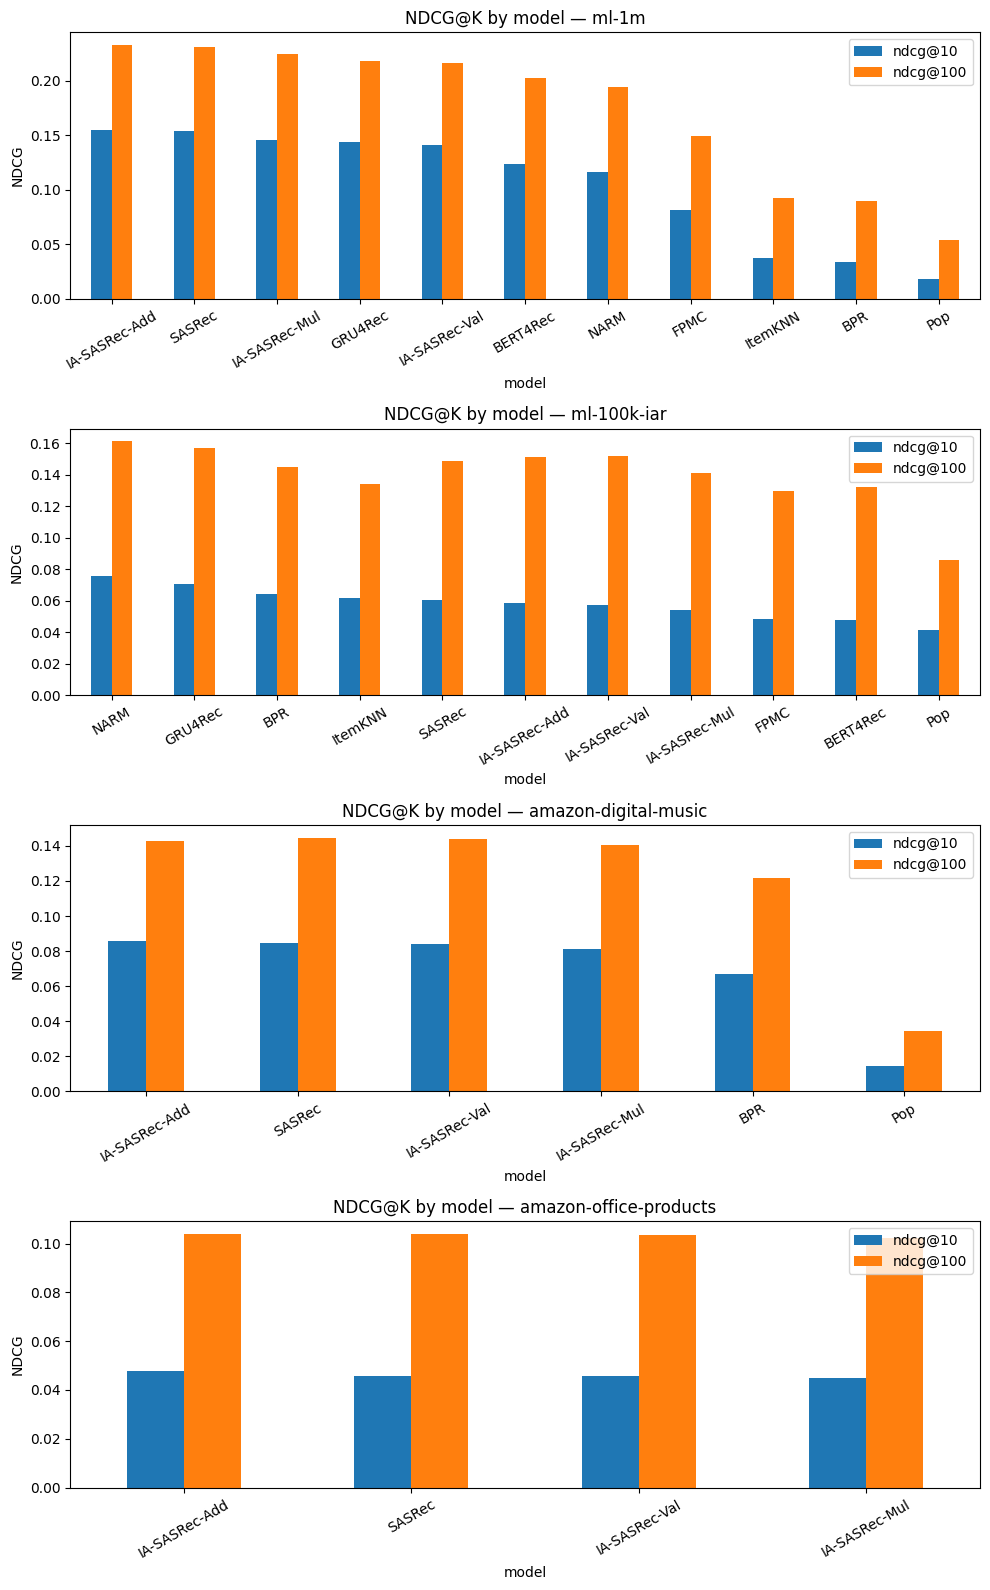

In [ ]:
import matplotlib.pyplot as plt
ndcg_cols = ['ndcg@10', 'ndcg@20', 'ndcg@50', 'ndcg@100']
fig, axes = plt.subplots(len(tables), 1, figsize=(10, 4 * len(tables)), squeeze=False)
for ax, (ds, tbl) in zip(axes.flatten(), tables.items()):
    cols = [c for c in ndcg_cols if c in tbl.columns]
    tbl.set_index('model')[cols].plot.bar(ax=ax)
    ax.set_ylabel('NDCG'); ax.set_title(f'NDCG@K by model — {ds}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()

## 5. Top-100 recommendations demo

Confirms the "next-1 → top-K" path: for the best model on each dataset we
score the entire item vocab at the next position, mask items already in the
user's history, and take the top 100. Models are reloaded from their
checkpoints.

In [ ]:
from pathlib import Path
import numpy as np
from recbole.utils import get_model, init_seed
from recbole.data import create_dataset, data_preparation
from runner import _build_config

topk_per_dataset = {}
for ds, tbl in tables.items():
    best_model_name = tbl.iloc[0]['model']
    print(f'\n=== {ds} | best model: {best_model_name} ===')
    rec = load_result(ds, best_model_name)
    ckpt = str(config.CHECKPOINT_DIR / Path(rec['checkpoint']).name)

    cfg, model_cls = _build_config(ds, best_model_name, rec.get('best_params') or {}, epochs=1, saved=True)
    init_seed(cfg['seed'], cfg['reproducibility'])
    dataset = create_dataset(cfg)
    train_data, valid_data, test_data = data_preparation(cfg, dataset)
    model_class = model_cls or get_model(cfg['model'])
    model = model_class(cfg, train_data._dataset).to(cfg['device'])
    model.load_state_dict(torch.load(ckpt, map_location=cfg['device'])['state_dict'])
    model.eval()

    sample_users = list(dataset.id2token(dataset.uid_field, np.arange(1, 4)))
    topk_per_dataset[ds] = top_k_recommend(model, dataset, test_data, sample_users, k=100)
    print(topk_per_dataset[ds].head(5).to_string(index=False))


=== ml-1m | best model: IA-SASRec-Add ===


Max value of user's history interaction records has reached 66.60813579163009% of the total.


user_id  rank item_id    score
      1     1     357 4.211785
      1     2      39 4.137841
      1     3    1641 4.132287
      1     4     348 4.045329
      1     5    1094 4.015411

=== ml-100k-iar | best model: NARM ===


Max value of user's history interaction records has reached 47.925925925925924% of the total.


user_id  rank item_id    score
      1     1     444 1.754580
      1     2     576 1.406417
      1     3     336 1.335033
      1     4     291 1.247698
      1     5     449 1.227659

=== amazon-digital-music | best model: IA-SASRec-Add ===
             user_id  rank    item_id    score
A08161909WK3HU7UYTMW     1 B003JYOFIW 7.849484
A08161909WK3HU7UYTMW     2 B002ZTIIXK 4.931972
A08161909WK3HU7UYTMW     3 B0030NL8KK 4.851419
A08161909WK3HU7UYTMW     4 B002HQWQB6 4.847675
A08161909WK3HU7UYTMW     5 B004K4AUZW 4.824359

=== amazon-office-products | best model: IA-SASRec-Add ===
              user_id  rank    item_id    score
A00473363TJ8YSZ3YAGG9     1 B000MFHX3U 6.143979
A00473363TJ8YSZ3YAGG9     2 B005X9VZ70 5.725433
A00473363TJ8YSZ3YAGG9     3 B008I213WQ 4.837255
A00473363TJ8YSZ3YAGG9     4 B006W0HQ54 4.832437
A00473363TJ8YSZ3YAGG9     5 B005MR4QLU 4.633010


## 6. Analysis

In [ ]:
rows = []
for ds, tbl in tables.items():
    is_seq = {n: (MODEL_REGISTRY[n]['type'] == 'sequential') for n in tbl['model']}
    family = tbl['model'].map(lambda n: 'sequential' if is_seq[n] else 'general')
    grouped = (
        tbl.assign(family=family)
           .groupby('family')[[c for c in ['ndcg@10', 'hit@10', 'mrr@10'] if c in tbl.columns]]
           .mean()
           .round(4)
    )
    grouped['dataset'] = ds
    rows.append(grouped.reset_index())
pd.concat(rows, ignore_index=True).set_index(['dataset', 'family'])

ndcg@10  hit@10  mrr@10
dataset                family                             
ml-1m                  general      0.0297  0.0599  0.0207
                       sequential   0.1325  0.2434  0.0988
ml-100k-iar            general      0.0557  0.1064  0.0406
                       sequential   0.0590  0.1245  0.0394
amazon-digital-music   general      0.0405  0.0760  0.0297
                       sequential   0.0839  0.1809  0.0542
amazon-office-products sequential   0.0460  0.0952  0.0310

## 7. Adding a custom variant

For your next paper, drop a class into [`src/models/variants/`](../src/models/variants/)
and register it. Example:

```python
# src/models/variants/sasrec_plus.py
from recbole.model.sequential_recommender.sasrec import SASRec
import torch.nn as nn

class SASRecPlus(SASRec):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.extra_proj = nn.Linear(self.hidden_size, self.hidden_size)
    def forward(self, item_seq, item_seq_len):
        out = super().forward(item_seq, item_seq_len)
        return out + self.extra_proj(out)  # toy modification
```

Then in [`src/models/__init__.py`](../src/models/__init__.py):

```python
from models.variants.sasrec_plus import SASRecPlus
MODEL_REGISTRY['SASRecPlus'] = {
    'class': SASRecPlus,
    'type': 'sequential',
    'search_space': sasrec_space,
    'static': _seq_static(),
}
```

Re-run section 3 — only `SASRecPlus` will train; everything else loads from disk.